# 04 - Hybrid Mode-Enumeration + Gradient Distance Recovery

Analytic/scan mode enumeration supplies global basin starts; JAX-gradient L-BFGS-B refines locally in scaled distance coordinates. Notebook 03 remains unchanged for beam comparison.


In [93]:
from pathlib import Path
import sys
import time
import copy
import importlib

import jax
import jax.numpy as jnp
from scipy.signal import find_peaks

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

HERE = Path.cwd()
sys.path.insert(0, str((HERE / "../CW_lnL_check").resolve()))

import cw_helpers
importlib.reload(cw_helpers)

from cw_helpers import (
    build_disco_likelihood,
    build_fast_scan_likelihood,
    build_enterprise_pta,
    build_pure_cw_likelihood,
    compute_mode_spacing,
    enumerate_pulsar_modes,
    generate_injection_params,
    inject_noisefree_cw,
    load_pulsars,
    make_distance_optimizer,
    scan_pulsar_distance,
    scan_pulsar_pair_2d,
    simulate,
)

print(HERE)

/home/mattm/projects/HSYMT/lnL_distance_scans


## Control Panel

In [111]:
# Dataset knobs
DATA_MODE = "pure"            # "pure" or "stochastic"
N_PSR = 20                    # use <=80 with discovery HD GWB
N_CW = 4
LOG10_H = -12.0
LOG10_MC = None
RNG_SEED = 12345
NOISE_SEED = 24680

# Truth-vs-prior split
TRUTH_DISTANCE_MODE = "gaussian_prior_draw"  # "prior_mean", "gaussian_prior_draw", "sigma_offset"
TRUTH_SIGMA_OFFSET = 1.0
TRUTH_SIGMA_CLIP = 3.0

# Stochastic mode knobs
STOCHASTIC_SCENARIO = "well_separated"
COMPONENTS = 10
INCLUDE_GWB = True
GWB_LOG10_A = -17.5
GWB_GAMMA = 13/3

# Pair ordering
PAIR_MODE = "anchor_ladder"   # "anchor", "anchor_ladder", "all"
MAX_PAIRS_PER_SWEEP = 0       # 0 = full chosen schedule

# Robust candidate generation. Increase these only if candidate truth coverage is poor.
MODE_PRIOR_SIGMA_WIDTH = 3.0
MODE_SAMPLES_PER_MODE = 6
MAX_1D_SCAN_POINTS = 5000
TOP_MODE_CANDIDATES = 60
N_CONTEXT_RANDOM = 3          # extra conditioning contexts for 1D candidate scans
CONTEXT_SIGMA_CLIP = 3.0

# Beam optimizer. Fast defaults use two-stage pair scan: candidate centers -> tiny local refinement.
BEAM_WIDTH = 12
ELITE_BEAM_WIDTH = 4             # always keep top lnL states
DIVERSE_BEAM_WIDTH = 8           # also keep mode-diverse states, even if lower lnL
ACTIVE_BEAM_WIDTH_PER_PAIR = 12    # scan only top active states each pair; carry rest forward unchanged
BEAM_RANDOM_STATES = 64          # random combinations of candidate modes
RAW_PRIOR_RANDOM_STATES = 16       # raw Gaussian-prior starts, same distribution family as truth
PAIR_CENTER_K = 6                 # candidate centers per pulsar for coarse pair center scan
PAIR_REFINE_TOP_N = 4             # refine this many center-scan peaks
PAIR_PROPOSALS_PER_STATE = 4        # keep this many pair-update proposals per active state             # local refinement patches around top center-scan peaks
PAIR_LOCAL_HALF_WIDTH_MODES = 0.75
PAIR_LOCAL_POINTS_PER_MODE = 2
PAIR_LOCAL_MIN_POINTS = 5
BEAM_MAX_SWEEPS = 2
FORCE_TRUTH_IN_PAIR_GRIDS_FOR_DEBUG = False # keep False for real optimizer; diagnostics force truth separately
CHUNK_SIZE = None

# Display / progress
PLOT_DURING_RUN = False
PLOT_EVERY_PAIR = 10
PROGRESS_EVERY_PAIR = 1
KEEP_PAIR_RECORDS = 20
# Candidate generation
CANDIDATE_MODE = "empirical"  # "empirical" or "analytic"

# Gradient optimizer controls
MODE_ENUM_SHORT_SCAN_POINTS = 80
GRADIENT_MODE_STARTS = 50
GRADIENT_PRIOR_STARTS = 20
GRADIENT_MAXITER = 200
MODE_SWITCH_MAX_ROUNDS = 3
MODE_SWITCH_GROUPS = True
RUN_MODE_SPACING_VALIDATION = True
RUN_MODE_ENUMERATION = True
RUN_GRADIENT_OPTIMIZER = True
RUN_MODE_SWITCHING = True
RUN_BEAM_FOR_TIMING_COMPARISON = False
MODE_SWITCH_CANDIDATES_PER_PSR = 15
MODE_SWITCH_GROUP_CANDIDATES_PER_PSR = 8
MODE_SWITCH_GROUP_TOP_PULSARS = 5
MODE_SWITCH_MAX_TRIALS = 800
MODE_SWITCH_SECONDS_BUDGET = 1800
MODE_SWITCH_PULSAR_ORDER = "hard_first"  # "hard_first" or "index"
MODE_SWITCH_RESCUE_CANDIDATES_PER_PSR = 120
MODE_SWITCH_RESCUE_EXTRA_HARD_PULSARS = 3

# Staged tests
RUN_TEST_FULL_TRUTH_START = True


## Helpers

In [95]:
CW_LIBRARY = [
    dict(cos_gwtheta=0.30, gwphi=2.50, cos_inc=-0.20, phase0=1.00, psi=0.70, log10_h=-12.0, log10_mc=9.00, log10_fgw=-8.00),
    dict(cos_gwtheta=-0.50, gwphi=0.80, cos_inc=0.40, phase0=2.10, psi=1.30, log10_h=-12.0, log10_mc=9.00, log10_fgw=-7.80),
    dict(cos_gwtheta=0.05, gwphi=4.20, cos_inc=-0.65, phase0=0.35, psi=2.30, log10_h=-12.0, log10_mc=9.00, log10_fgw=-8.20),
    dict(cos_gwtheta=0.70, gwphi=5.40, cos_inc=0.10, phase0=1.70, psi=0.20, log10_h=-12.0, log10_mc=9.00, log10_fgw=-7.90),
    dict(cos_gwtheta=-0.10, gwphi=3.30, cos_inc=0.80, phase0=2.90, psi=1.80, log10_h=-12.0, log10_mc=9.00, log10_fgw=-8.10),
]


def clipped_normal(mean, sigma, rng, clip):
    draw = rng.normal(mean, sigma)
    lo = np.maximum(0.01, mean - clip * sigma)
    hi = mean + clip * sigma
    return np.clip(draw, lo, hi)


def select_pulsars(n_psr):
    ent_all, disco_all = load_pulsars(None)
    pairs = sorted(zip(ent_all, disco_all), key=lambda pair: pair[1].pdist[1])
    selected = pairs[:n_psr]
    return [p[0] for p in selected], [p[1] for p in selected], len(disco_all)


def clone_psrs_with_distances(psrs, distances):
    clones = copy.deepcopy(psrs)
    for psr, dist in zip(clones, distances):
        sigma = float(psr.pdist[1])
        try:
            psr.pdist = (float(dist), sigma)
        except Exception:
            psr._pdist = (float(dist), sigma)
    return clones


def make_truth_distances(prior_mean, prior_sigma, rng):
    if TRUTH_DISTANCE_MODE == "prior_mean":
        return prior_mean.copy()
    if TRUTH_DISTANCE_MODE == "gaussian_prior_draw":
        return clipped_normal(prior_mean, prior_sigma, rng, TRUTH_SIGMA_CLIP)
    if TRUTH_DISTANCE_MODE == "sigma_offset":
        signs = rng.choice([-1.0, 1.0], size=len(prior_mean))
        return np.maximum(0.01, prior_mean + signs * TRUTH_SIGMA_OFFSET * prior_sigma)
    raise ValueError(TRUTH_DISTANCE_MODE)


def cw_params_from_library(n_cw, log10_h=None, log10_mc=None):
    if n_cw > len(CW_LIBRARY):
        raise ValueError(f"N_CW={n_cw} exceeds CW_LIBRARY size={len(CW_LIBRARY)}")
    out = [dict(cw) for cw in CW_LIBRARY[:n_cw]]
    for cw in out:
        if log10_h is not None:
            cw["log10_h"] = log10_h
        if log10_mc is not None:
            cw["log10_mc"] = log10_mc
    return out


def cw_list_from_enterprise_params(enterprise_params, cw_block_names):
    keys = ("cos_gwtheta", "gwphi", "cos_inc", "log10_mc", "log10_fgw", "log10_h", "phase0", "psi")
    return [{key: float(enterprise_params[f"{name}_{key}"]) for key in keys} for name in cw_block_names]


def make_pair_schedule(n_psr, mode):
    if mode == "all":
        pairs = [(i, j) for i in range(n_psr) for j in range(i + 1, n_psr)]
    elif mode == "anchor":
        pairs = [(0, j) for j in range(1, n_psr)]
    elif mode == "anchor_ladder":
        pairs = [(0, j) for j in range(1, n_psr)]
        pairs += [(j, j + 1) for j in range(1, n_psr - 1)]
        pairs = list(dict.fromkeys(pairs))
    else:
        raise ValueError(mode)
    return pairs[:MAX_PAIRS_PER_SWEEP] if MAX_PAIRS_PER_SWEEP else pairs


def distance_key(psr):
    return f"{psr.name}_cw_p_dist"


def set_distances(values, param_keys, disco_psrs, distances):
    out = np.array(values, dtype=float).copy()
    for psr, dist in zip(disco_psrs, distances):
        out[param_keys.index(distance_key(psr))] = dist
    return out


def get_distances(values, param_keys, disco_psrs):
    return np.array([float(values[param_keys.index(distance_key(psr))]) for psr in disco_psrs])


def min_mode_spacings(disco_psrs, cw_params_list):
    out = []
    for psr in disco_psrs:
        vals = [compute_mode_spacing(cw["cos_gwtheta"], cw["gwphi"], cw["log10_fgw"], psr.pos) for cw in cw_params_list]
        out.append(float(np.nanmin(vals)))
    return np.array(out)


def recovery_score(distances):
    err = distances - truth_dist
    em = err / mode_spacings
    es = err / sigmas
    return dict(
        frac_within_half_mode=float(np.mean(np.abs(em) < 0.5)),
        frac_within_one_mode=float(np.mean(np.abs(em) < 1.0)),
        median_abs_modes=float(np.median(np.abs(em))),
        max_abs_modes=float(np.max(np.abs(em))),
        median_abs_sigma=float(np.median(np.abs(es))),
        max_abs_sigma=float(np.max(np.abs(es))),
    )


def top_local_maxima(x, y, k):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(y)
    x, y = x[finite], y[finite]
    if len(x) == 0:
        return np.array([]), np.array([])
    if len(x) >= 3:
        idx = np.where(np.r_[False, (y[1:-1] >= y[:-2]) & (y[1:-1] >= y[2:]), False])[0]
    else:
        idx = np.array([], dtype=int)
    if len(idx) < k:
        idx = np.unique(np.r_[idx, np.argsort(y)[::-1]])
    idx = idx[np.argsort(y[idx])[::-1]][:k]
    return x[idx], y[idx]


def candidate_grid_bounds(i):
    lo = max(0.01, prior_mean[i] - MODE_PRIOR_SIGMA_WIDTH * sigmas[i])
    hi = prior_mean[i] + MODE_PRIOR_SIGMA_WIDTH * sigmas[i]
    dL = mode_spacings[i]
    if not np.isfinite(dL) or dL <= 0:
        n_points = MAX_1D_SCAN_POINTS
    else:
        n_points = int(np.ceil((hi - lo) / dL * MODE_SAMPLES_PER_MODE)) + 1
        n_points = int(np.clip(n_points, 25, MAX_1D_SCAN_POINTS))
    return lo, hi, n_points


def local_grid_around_centers(centers, i):
    lo, hi, _ = candidate_grid_bounds(i)
    dL = mode_spacings[i]
    centers = np.asarray(centers, dtype=float)
    centers = centers[np.isfinite(centers)]
    if len(centers) == 0:
        return np.linspace(lo, hi, PAIR_LOCAL_MIN_POINTS)
    half = PAIR_LOCAL_HALF_WIDTH_MODES * dL if np.isfinite(dL) and dL > 0 else 0.1 * (hi - lo)
    n = int(max(PAIR_LOCAL_MIN_POINTS, np.ceil(2 * PAIR_LOCAL_HALF_WIDTH_MODES * PAIR_LOCAL_POINTS_PER_MODE + 1)))
    pieces = []
    for c in centers:
        a = max(lo, c - half)
        b = min(hi, c + half)
        pieces.append(np.linspace(a, b, n) if b > a else np.array([np.clip(c, lo, hi)]))
    return np.unique(np.concatenate(pieces))


def dedupe_beam(states, max_states):
    seen = set()
    out = []
    for st in sorted(states, key=lambda s: s["lnL"], reverse=True):
        key = tuple(np.round(st["distances"] / mode_spacings, 2))
        if key in seen:
            continue
        seen.add(key)
        out.append(st)
        if len(out) >= max_states:
            break
    return out


def nearest_grid_value(grid, x):
    grid = np.asarray(grid, dtype=float)
    idx = int(np.nanargmin(np.abs(grid - x)))
    return idx, float(grid[idx])


def draw_truth_crosshair(ax, truth_i, truth_j):
    ax.axvline(truth_j, color="black", lw=3.0, ls="--", alpha=0.9, zorder=8)
    ax.axhline(truth_i, color="black", lw=3.0, ls="--", alpha=0.9, zorder=8)
    ax.axvline(truth_j, color="magenta", lw=1.6, ls="--", alpha=0.95, zorder=9, label="truth")
    ax.axhline(truth_i, color="magenta", lw=1.6, ls="--", alpha=0.95, zorder=9)


def set_pair_plot_limits(ax, grid_i, grid_j, truth_i, truth_j, pad_frac=0.05):
    xvals = np.asarray(list(grid_j) + [truth_j], dtype=float)
    yvals = np.asarray(list(grid_i) + [truth_i], dtype=float)
    xmin, xmax = np.nanmin(xvals), np.nanmax(xvals)
    ymin, ymax = np.nanmin(yvals), np.nanmax(yvals)
    ax.set_xlim(xmin - max((xmax - xmin) * pad_frac, 1e-9), xmax + max((xmax - xmin) * pad_frac, 1e-9))
    ax.set_ylim(ymin - max((ymax - ymin) * pad_frac, 1e-9), ymax + max((ymax - ymin) * pad_frac, 1e-9))


def unique_sorted(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    return np.unique(vals)


def center_values_for_pulsar(state, i):
    vals = [state["distances"][i], prior_mean[i]]
    vals += list(mode_candidates[i]["distances"][:PAIR_CENTER_K])
    if FORCE_TRUTH_IN_PAIR_GRIDS_FOR_DEBUG:
        vals.append(truth_dist[i])
    lo, hi, _ = candidate_grid_bounds(i)
    vals = np.clip(vals, lo, hi)
    return unique_sorted(vals)


def local_grid_single(center, i):
    lo, hi, _ = candidate_grid_bounds(i)
    dL = mode_spacings[i]
    half = PAIR_LOCAL_HALF_WIDTH_MODES * dL if np.isfinite(dL) and dL > 0 else 0.02 * (hi - lo)
    n = int(max(PAIR_LOCAL_MIN_POINTS, np.ceil(2 * PAIR_LOCAL_HALF_WIDTH_MODES * PAIR_LOCAL_POINTS_PER_MODE + 1)))
    a = max(lo, center - half)
    b = min(hi, center + half)
    grid = np.linspace(a, b, n) if b > a else np.array([np.clip(center, lo, hi)])
    if FORCE_TRUTH_IN_PAIR_GRIDS_FOR_DEBUG:
        grid = np.unique(np.r_[grid, truth_dist[i]])
    return grid


def top_surface_indices(surf, n):
    flat = np.asarray(surf).ravel()
    finite = np.where(np.isfinite(flat))[0]
    if len(finite) == 0:
        return []
    order = finite[np.argsort(flat[finite])[::-1]]
    out = []
    seen = set()
    for idx in order:
        ij = np.unravel_index(idx, surf.shape)
        if ij in seen:
            continue
        seen.add(ij)
        out.append(ij)
        if len(out) >= n:
            break
    return out


def mode_vector(distances):
    return np.asarray(distances, dtype=float) / mode_spacings


def select_diverse_beam(states, max_states=None):
    """Keep high-lnL states plus mode-diverse lower-lnL states.

    Pure lnL pruning can kill intermediate states needed to cross between
    multimodal basins. This selection keeps elites, then greedily adds states
    far from already-kept states in mode-index space.
    """
    max_states = BEAM_WIDTH if max_states is None else max_states
    sorted_states = sorted(states, key=lambda s: s["lnL"], reverse=True)
    deduped = []
    seen = set()
    for st in sorted_states:
        key = tuple(np.round(mode_vector(st["distances"]), 2))
        if key in seen:
            continue
        seen.add(key)
        deduped.append(st)

    kept = deduped[:min(ELITE_BEAM_WIDTH, max_states)]
    remaining = deduped[min(ELITE_BEAM_WIDTH, max_states):]
    while remaining and len(kept) < max_states:
        kept_vecs = np.array([mode_vector(st["distances"]) for st in kept])
        best_idx = None
        best_score = -np.inf
        for idx, st in enumerate(remaining):
            v = mode_vector(st["distances"])
            dist = np.min(np.sqrt(np.mean((kept_vecs - v[None, :]) ** 2, axis=1)))
            # mostly diversity, slight lnL tie-breaker after scaling.
            score = dist + 1e-6 * (st["lnL"] - deduped[0]["lnL"])
            if score > best_score:
                best_score = score
                best_idx = idx
        kept.append(remaining.pop(best_idx))
    return kept


def mutate_beam_state(state, n_mutations=2):
    """Randomly replace a few pulsars by candidate modes to seed bridge states."""
    d = state["distances"].copy()
    idxs = rng.choice(np.arange(len(disco_psrs)), size=min(n_mutations, len(d)), replace=False)
    for i in idxs:
        c = mode_candidates[i]
        if len(c["distances"]):
            # use flatter distribution than candidate init
            d[i] = rng.choice(c["distances"])
    vals = set_distances(base_values, param_keys, disco_psrs, d)
    return dict(label=f"mutated_{state.get('label', 'beam')}", distances=d, values=vals, lnL=float(logl_fn(vals)))


## Build Injection and Likelihood

In [96]:
rng = np.random.default_rng(RNG_SEED)
np.random.seed(NOISE_SEED)

t0 = time.time()
ent_psrs, disco_psrs, total_loaded = select_pulsars(N_PSR)
prior_mean = np.array([p.pdist[0] for p in disco_psrs], dtype=float)
sigmas = np.array([p.pdist[1] for p in disco_psrs], dtype=float)
truth_dist = make_truth_distances(prior_mean, sigmas, rng)

ent_psrs_inj = clone_psrs_with_distances(ent_psrs, truth_dist)
disco_psrs_inj = clone_psrs_with_distances(disco_psrs, truth_dist)

if DATA_MODE == "pure":
    cw_params_list = cw_params_from_library(N_CW, LOG10_H, LOG10_MC)
    residual_map, _ = inject_noisefree_cw(disco_psrs_inj, cw_params_list)
    logl_fn, param_keys, base_values = build_pure_cw_likelihood(disco_psrs, residual_map, cw_params_list)
    enterprise_params = None
    cw_block_names = None
else:
    pta, cw_block_names, _ = build_enterprise_pta(ent_psrs_inj, N_CW, components=COMPONENTS)
    enterprise_params = generate_injection_params(
        pta, ent_psrs_inj, N_CW, cw_block_names,
        log10_h=LOG10_H,
        scenario=STOCHASTIC_SCENARIO,
        rng=rng,
        gwb_log10_A=GWB_LOG10_A,
        gwb_gamma=GWB_GAMMA,
    )
    if LOG10_MC is not None:
        for name in cw_block_names:
            enterprise_params[f"{name}_log10_mc"] = LOG10_MC
    cw_params_list = cw_list_from_enterprise_params(enterprise_params, cw_block_names)
    sim_resids = simulate(pta, enterprise_params, sparse_cholesky=True)
    residual_map = {getattr(p, "name", p): y for p, y in zip(pta.pulsars, sim_resids)}
    logl_fn_disco, param_keys_disco, base_values_disco = build_disco_likelihood(
        disco_psrs, residual_map,
        num_cw=N_CW,
        enterprise_params=enterprise_params,
        cw_block_names=cw_block_names,
        components=COMPONENTS,
        include_gwb=INCLUDE_GWB,
    )
    if INCLUDE_GWB:
        try:
            logl_fn_fast, param_keys_fast, base_values_fast = build_fast_scan_likelihood(
                disco_psrs, residual_map,
                num_cw=N_CW,
                enterprise_params=enterprise_params,
                cw_block_names=cw_block_names,
                components=COMPONENTS,
            )
            if param_keys_fast != param_keys_disco:
                print("WARNING: fast/disco param key order differs; falling back to discovery likelihood.")
                logl_fn, param_keys, base_values = logl_fn_disco, param_keys_disco, base_values_disco
            else:
                truth_probe = set_distances(base_values_fast, param_keys_fast, disco_psrs, truth_dist)
                ll_fast = float(logl_fn_fast(jnp.asarray(truth_probe)))
                ll_disco = float(logl_fn_disco(jnp.asarray(truth_probe)))
                grad_probe = jax.grad(logl_fn_fast)(jnp.asarray(truth_probe))
                grad_finite = bool(np.all(np.isfinite(np.asarray(grad_probe))))
                print(f"fast/disco truth lnL Δ={ll_fast-ll_disco:.3e}; fast grad finite={grad_finite}")
                if abs(ll_fast - ll_disco) > 1e-6 or not grad_finite:
                    print("WARNING: fast-scan validation failed; falling back to discovery likelihood.")
                    logl_fn, param_keys, base_values = logl_fn_disco, param_keys_disco, base_values_disco
                else:
                    logl_fn, param_keys, base_values = logl_fn_fast, param_keys_fast, base_values_fast
        except Exception as e:
            print(f"WARNING: fast-scan likelihood failed ({e}); falling back to discovery likelihood.")
            logl_fn, param_keys, base_values = logl_fn_disco, param_keys_disco, base_values_disco
    else:
        print("WARNING: build_fast_scan_likelihood requires GWB globalgp; using discovery likelihood.")
        logl_fn, param_keys, base_values = logl_fn_disco, param_keys_disco, base_values_disco

mode_spacings = min_mode_spacings(disco_psrs, cw_params_list)
pair_schedule = make_pair_schedule(N_PSR, PAIR_MODE)
prior_mean_values = np.array(base_values, dtype=float)
truth_values = set_distances(base_values, param_keys, disco_psrs, truth_dist)
prior_mean_lnL = float(logl_fn(prior_mean_values))
truth_lnL = float(logl_fn(truth_values))

print(f"loaded total pulsars: {total_loaded}")
print(f"selected N_PSR: {N_PSR}")
print(f"N_CW: {N_CW}, DATA_MODE={DATA_MODE}")
print(f"pair schedule: {PAIR_MODE}, pairs/sweep={len(pair_schedule)}")
print(f"truth lnL: {truth_lnL:.3f}")
print(f"prior mean lnL: {prior_mean_lnL:.3f}, Δ={prior_mean_lnL-truth_lnL:.3f}")
print(f"mode spacing min/median/max: {np.nanmin(mode_spacings):.3g} / {np.nanmedian(mode_spacings):.3g} / {np.nanmax(mode_spacings):.3g} kpc")
print(f"build+JIT seconds: {time.time()-t0:.1f}")

display(pd.DataFrame({
    "pulsar": [p.name for p in disco_psrs],
    "prior_mean_kpc": prior_mean,
    "truth_kpc": truth_dist,
    "truth_minus_prior_sigma": (truth_dist - prior_mean) / sigmas,
    "sigma_kpc": sigmas,
    "min_mode_spacing_kpc": mode_spacings,
    "sigma_over_mode": sigmas / mode_spacings,
}))

FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cann

,pulsar,prior_mean_kpc,truth_kpc,truth_minus_prior_sigma,sigma_kpc,min_mode_spacing_kpc,sigma_over_mode
0,J0437-4715,0.1549,0.153476,-1.423825,0.0010,0.000441,2.268828
1,J0030+0451,0.3296,0.334149,1.263728,0.0036,0.000589,6.113317
2,J1744-1134,0.4141,0.406003,-0.870662,0.0093,0.000397,23.407693
3,J1909-3744,1.1590,1.155631,-0.259173,0.0130,0.000542,23.965268
4,J1022+1001,0.7060,0.704568,-0.075343,0.0190,0.000447,42.478007
5,J1713+0747,1.1380,1.123923,-0.740885,0.0190,0.000343,55.356551
6,J0711-6830,0.1060,0.077003,-1.367793,0.0212,0.000408,51.914590
7,J1012+5307,0.8620,0.876276,0.648893,0.0220,0.000395,55.649773
8,J1730-2304,0.5290,0.536943,0.361058,0.0220,0.000426,51.666250
9,J2145-0750,0.6240,0.581037,-1.952863,0.0220,0.000491,44.823511


## Truth / Prior / Start Audit

Checks that injected truth is not just the EM prior mean, and later shows initial optimizer starts.

In [97]:
truth_prior_audit = pd.DataFrame({
    "pulsar": [p.name for p in disco_psrs],
    "prior_mean_kpc": prior_mean,
    "truth_kpc": truth_dist,
    "truth_minus_prior_sigma": (truth_dist - prior_mean) / sigmas,
    "truth_minus_prior_modes": (truth_dist - prior_mean) / mode_spacings,
})
display(truth_prior_audit)
print("max |truth-prior| / sigma:", np.max(np.abs(truth_prior_audit["truth_minus_prior_sigma"])))
print("any exact truth==prior mean:", bool(np.any(np.isclose(truth_dist, prior_mean, rtol=0, atol=1e-14))))
print("TRUTH_DISTANCE_MODE:", TRUTH_DISTANCE_MODE)
print("FORCE_TRUTH_IN_PAIR_GRIDS_FOR_DEBUG:", FORCE_TRUTH_IN_PAIR_GRIDS_FOR_DEBUG)


,pulsar,prior_mean_kpc,truth_kpc,truth_minus_prior_sigma,truth_minus_prior_modes
0,J0437-4715,0.1549,0.153476,-1.423825,-3.230414
1,J0030+0451,0.3296,0.334149,1.263728,7.725573
2,J1744-1134,0.4141,0.406003,-0.870662,-20.380182
3,J1909-3744,1.1590,1.155631,-0.259173,-6.211156
4,J1022+1001,0.7060,0.704568,-0.075343,-3.200434
5,J1713+0747,1.1380,1.123923,-0.740885,-41.012819
6,J0711-6830,0.1060,0.077003,-1.367793,-71.008397
7,J1012+5307,0.8620,0.876276,0.648893,36.110737
8,J1730-2304,0.5290,0.536943,0.361058,18.654519
9,J2145-0750,0.6240,0.581037,-1.952863,-87.534180


max |truth-prior| / sigma: 2.3474096543788523
any exact truth==prior mean: False
TRUTH_DISTANCE_MODE: gaussian_prior_draw
FORCE_TRUTH_IN_PAIR_GRIDS_FOR_DEBUG: False


## Section A - Mode Spacing Validation

High-resolution 1D scans for a small diagnostic subset. This catches sign/formula errors before optimizer work.

In [98]:
def empirical_peak_spacings(scan_d, scan_ll, dL):
    finite = np.isfinite(scan_ll)
    if finite.sum() < 5:
        return np.array([]), np.array([])
    y = np.asarray(scan_ll, dtype=float)
    prom = max(0.1, 0.02 * (np.nanmax(y) - np.nanmin(y)))
    min_dx = np.nanmedian(np.diff(scan_d)) if len(scan_d) > 1 else dL / 10
    min_dist = max(1, int(0.4 * dL / max(min_dx, 1e-12))) if np.isfinite(dL) else 3
    peaks, props = find_peaks(y, prominence=prom, distance=min_dist)
    peak_d = np.asarray(scan_d)[peaks]
    if len(peak_d) < 2:
        return peak_d, np.array([])
    return peak_d, np.diff(np.sort(peak_d))


def validate_mode_spacing(diagnostic_indices=None, n_points=3000):
    """Validate analytic mode spacing against empirical scans.

    Uses SINGLE-CW likelihoods so each CW spacing is measured independently
    without multi-CW interference. Currently supported only for DATA_MODE='pure'.
    """
    if DATA_MODE != "pure":
        print("Single-CW validation only supported for DATA_MODE='pure'")
        return pd.DataFrame()
    if diagnostic_indices is None:
        diagnostic_indices = np.linspace(0, N_PSR - 1, min(5, N_PSR), dtype=int)
    rows = []
    truth_ctx_values = set_distances(base_values, param_keys, disco_psrs, truth_dist)

    for k, cw in enumerate(cw_params_list):
        single_cw_list = [cw]
        try:
            single_logl, single_keys, single_base = build_pure_cw_likelihood(
                disco_psrs, residual_map, single_cw_list
            )
            single_truth = set_distances(single_base, single_keys, disco_psrs, truth_dist)
        except Exception as e:
            print(f"WARNING: could not build single-CW likelihood for CW {k}: {e}")
            single_logl = logl_fn
            single_keys = param_keys
            single_truth = truth_ctx_values

        for i in diagnostic_indices:
            psr = disco_psrs[i]
            dL = float(compute_mode_spacing(cw["cos_gwtheta"], cw["gwphi"], cw["log10_fgw"], psr.pos))
            if not np.isfinite(dL) or dL <= 0:
                rows.append(dict(
                    pulsar=psr.name, pulsar_index=i, cw=k,
                    analytic_dL=dL, empirical_dL=np.nan, rel_err=np.nan,
                    n_peaks=0, truth_near_analytic_mode=False,
                    warning="nonfinite dL",
                ))
                continue

            lo = max(0.01, truth_dist[i] - 6 * dL)
            hi = truth_dist[i] + 6 * dL
            dist_key = f"{psr.name}_cw_p_dist"
            if dist_key not in single_keys:
                matches = [key for key in single_keys if psr.name in key and "dist" in key]
                if matches:
                    dist_key = matches[0]
                else:
                    rows.append(dict(
                        pulsar=psr.name, pulsar_index=i, cw=k,
                        analytic_dL=dL, empirical_dL=np.nan, rel_err=np.nan,
                        n_peaks=0, truth_near_analytic_mode=False,
                        warning="dist key not found",
                    ))
                    continue

            vals, lls = scan_pulsar_distance(
                single_logl, single_truth, single_keys, dist_key,
                lo, hi, n_points=n_points, chunk_size=CHUNK_SIZE,
                n_components=COMPONENTS,
                required_points=[truth_dist[i], prior_mean[i]],
            )
            peak_d, spacings = empirical_peak_spacings(vals, lls, dL)
            emp = float(np.nanmedian(spacings)) if len(spacings) else np.nan
            rel = abs(emp - dL) / dL if np.isfinite(emp) else np.nan
            ref = peak_d[np.argmin(np.abs(peak_d - truth_dist[i]))] if len(peak_d) else prior_mean[i]
            nearest_mode = ref + np.round((truth_dist[i] - ref) / dL) * dL
            truth_near = abs(truth_dist[i] - nearest_mode) <= 0.3 * dL
            warning = ""
            if np.isfinite(rel) and rel > 0.10:
                warning = "SUSPECT"
                print(f"WARNING {psr.name} cw{k}: analytic dL={dL:.6g}, empirical={emp:.6g}, rel_err={rel:.3g}")
            rows.append(dict(
                pulsar=psr.name, pulsar_index=i, cw=k,
                analytic_dL=dL, empirical_dL=emp, rel_err=rel,
                n_peaks=len(peak_d), truth_near_analytic_mode=truth_near,
                warning=warning,
            ))
    return pd.DataFrame(rows)

if RUN_MODE_SPACING_VALIDATION:
    mode_spacing_validation_df = validate_mode_spacing()
    display(mode_spacing_validation_df)
else:
    print("Set RUN_MODE_SPACING_VALIDATION=True and rerun.")


,pulsar,pulsar_index,cw,analytic_dL,empirical_dL,rel_err,n_peaks,truth_near_analytic_mode,warning
0,J0437-4715,0,0,0.000935,0.000935,0.000333,11,True,
1,J1022+1001,4,0,0.032633,0.032513,0.003668,11,True,
2,J2145-0750,9,0,0.000491,0.000505,0.028343,11,True,
3,J2322-2650,14,0,0.000515,0.000519,0.008336,12,False,
4,J1045-4509,19,0,0.001700,0.001708,0.004335,11,True,
5,J0437-4715,0,1,0.006581,0.006570,0.001667,11,True,
6,J1022+1001,4,1,0.000447,0.000484,0.082361,11,True,
7,J2145-0750,9,1,0.000794,0.000823,0.036345,11,True,
8,J2322-2650,14,1,0.001836,0.001844,0.004335,11,True,
9,J1045-4509,19,1,0.000677,0.000699,0.032344,11,True,


## Section B - Mode Enumeration

Short scans anchor each CW mode family near the prior mean; `enumerate_pulsar_modes` scores pooled candidates against all CW families.

In [99]:
def nearest_peak_to_reference(scan_d, scan_ll, ref, fallback=None):
    fallback = ref if fallback is None else fallback
    y = np.asarray(scan_ll, dtype=float)
    prom = max(0.1, 0.02 * (np.nanmax(y) - np.nanmin(y))) if len(y) else 0.1
    peaks, props = find_peaks(y, prominence=prom, distance=2)
    if len(peaks) == 0:
        return float(fallback)
    peak_d = np.asarray(scan_d)[peaks]
    return float(peak_d[np.argmin(np.abs(peak_d - ref))])


def build_gradient_mode_candidates():
    all_modes = []
    all_scores = []
    enum_rows = []

    # Build conditioning contexts - NOT truth.
    contexts = [("prior_mean", prior_mean.copy())]
    for k in range(N_CONTEXT_RANDOM):
        contexts.append((f"random_{k}", clipped_normal(prior_mean, sigmas, rng, CONTEXT_SIGMA_CLIP)))

    t0 = time.time()
    for i, psr in enumerate(disco_psrs):
        empirical_refs_by_context = {}
        for ctx_name, ctx_dist in contexts:
            ctx_values = set_distances(base_values, param_keys, disco_psrs, ctx_dist)
            refs_this_ctx = {}
            for k, cw in enumerate(cw_params_list):
                dL = float(compute_mode_spacing(cw["cos_gwtheta"], cw["gwphi"], cw["log10_fgw"], psr.pos))
                if not np.isfinite(dL) or dL <= 0:
                    refs_this_ctx[k] = float(prior_mean[i])
                    continue
                lo = max(0.01, prior_mean[i] - dL)
                hi = prior_mean[i] + dL
                vals, lls = scan_pulsar_distance(
                    logl_fn, ctx_values, param_keys, distance_key(psr),
                    lo, hi, n_points=MODE_ENUM_SHORT_SCAN_POINTS,
                    chunk_size=CHUNK_SIZE, n_components=COMPONENTS,
                    required_points=[prior_mean[i]],
                )
                refs_this_ctx[k] = nearest_peak_to_reference(vals, lls, prior_mean[i], fallback=prior_mean[i])
            empirical_refs_by_context[ctx_name] = refs_this_ctx

        # Pool references across contexts. Each CW gets one robust reference anchor.
        pooled_refs = {}
        for k in range(len(cw_params_list)):
            ref_values = [empirical_refs_by_context[ctx][k] for ctx in empirical_refs_by_context]
            pooled_refs[k] = float(np.median(ref_values))

        modes, scores, per_cw_spacings = enumerate_pulsar_modes(
            psr, cw_params_list, prior_mean[i], sigmas[i],
            n_sigma=MODE_PRIOR_SIGMA_WIDTH,
            empirical_reference=pooled_refs,
            max_candidates=TOP_MODE_CANDIDATES,
        )
        all_modes.append(np.asarray(modes, dtype=float))
        all_scores.append(np.asarray(scores, dtype=float))
        min_dL = np.nanmin(per_cw_spacings)
        truth_in = bool(np.any(np.abs(modes - truth_dist[i]) <= 0.3 * min_dL)) if len(modes) else False
        enum_rows.append(dict(
            pulsar=psr.name, pulsar_index=i, n_candidates=len(modes),
            best_score=float(scores[0]) if len(scores) else np.nan,
            truth_in_candidates=truth_in,
            min_dL=float(min_dL), spacings=" / ".join(f"{x:.3g}" for x in per_cw_spacings),
        ))
        print(f"{i+1:02d}/{N_PSR} {psr.name}: modes={len(modes)}, truth_in={truth_in}, best_score={scores[0] if len(scores) else np.nan:.3g}")
    print(f"mode enumeration seconds: {time.time() - t0:.1f}")
    return all_modes, all_scores, pd.DataFrame(enum_rows)


def build_empirical_mode_candidates():
    """Generate candidate distance modes via full-width 1D likelihood scans.

    This pools top local maxima across prior/random conditioning contexts and
    does not depend on analytic mode spacing being correct.
    """
    all_modes = []
    all_scores = []
    enum_rows = []

    contexts = [("prior_mean", prior_mean.copy())]
    for k in range(N_CONTEXT_RANDOM):
        contexts.append((f"random_{k}", clipped_normal(prior_mean, sigmas, rng, CONTEXT_SIGMA_CLIP)))

    t0 = time.time()
    for i, psr in enumerate(disco_psrs):
        lo, hi, n_points = candidate_grid_bounds(i)
        dL = mode_spacings[i]
        n_modes_in_window = int(np.ceil((hi - lo) / dL)) if np.isfinite(dL) and dL > 0 else TOP_MODE_CANDIDATES
        adaptive_top = max(TOP_MODE_CANDIDATES, min(max(1, n_modes_in_window // 3), 200))
        all_peaks_d = []
        all_peaks_lnL = []

        for ctx_name, ctx_dist in contexts:
            ctx_values = set_distances(base_values, param_keys, disco_psrs, ctx_dist)
            vals, lls = scan_pulsar_distance(
                logl_fn, ctx_values, param_keys, distance_key(psr),
                lo, hi, n_points=n_points,
                chunk_size=CHUNK_SIZE, n_components=COMPONENTS,
                required_points=[prior_mean[i]],
            )
            peak_d, peak_lnL = top_local_maxima(vals, lls, adaptive_top)
            all_peaks_d.extend(peak_d)
            all_peaks_lnL.extend(peak_lnL)

        if len(all_peaks_d) == 0:
            all_modes.append(np.array([prior_mean[i]]))
            all_scores.append(np.array([0.0]))
            enum_rows.append(dict(
                pulsar=psr.name, pulsar_index=i, n_candidates=1,
                best_score=0.0, truth_in_candidates=False,
                min_dL=mode_spacings[i], spacings="empirical",
            ))
            continue

        all_peaks_d = np.asarray(all_peaks_d, dtype=float)
        all_peaks_lnL = np.asarray(all_peaks_lnL, dtype=float)
        order = np.argsort(all_peaks_lnL)[::-1]
        all_peaks_d = all_peaks_d[order]
        all_peaks_lnL = all_peaks_lnL[order]

        dedup_d = []
        dedup_lnL = []
        tol = 0.25 * dL if np.isfinite(dL) and dL > 0 else 1e-6
        for d, ll in zip(all_peaks_d, all_peaks_lnL):
            if len(dedup_d) == 0 or np.all(np.abs(np.asarray(dedup_d) - d) > tol):
                dedup_d.append(d)
                dedup_lnL.append(ll)
            if len(dedup_d) >= adaptive_top:
                break

        modes = np.asarray(dedup_d, dtype=float)
        scores = np.asarray(dedup_lnL, dtype=float)
        all_modes.append(modes)
        all_scores.append(scores)

        min_dL = mode_spacings[i]
        truth_in = bool(np.any(np.abs(modes - truth_dist[i]) <= 0.3 * min_dL)) if len(modes) else False
        enum_rows.append(dict(
            pulsar=psr.name, pulsar_index=i, n_candidates=len(modes),
            best_score=float(scores[0]) if len(scores) else np.nan,
            truth_in_candidates=truth_in,
            min_dL=float(min_dL), spacings="empirical",
        ))
        print(f"{i+1:02d}/{N_PSR} {psr.name}: modes={len(modes)}/{adaptive_top}, truth_in={truth_in}, best_lnL={scores[0] if len(scores) else np.nan:.3f}")

    print(f"empirical mode enumeration seconds: {time.time() - t0:.1f}")
    return all_modes, all_scores, pd.DataFrame(enum_rows)

if RUN_MODE_ENUMERATION:
    old_mode_enum_df = mode_enum_df.copy() if "mode_enum_df" in globals() else None
    if CANDIDATE_MODE == "empirical":
        all_pulsar_modes, all_pulsar_mode_scores, mode_enum_df = build_empirical_mode_candidates()
    elif CANDIDATE_MODE == "analytic":
        all_pulsar_modes, all_pulsar_mode_scores, mode_enum_df = build_gradient_mode_candidates()
    else:
        raise ValueError(f"Unknown CANDIDATE_MODE={CANDIDATE_MODE!r}")
    display(mode_enum_df)
    if old_mode_enum_df is not None and "truth_in_candidates" in old_mode_enum_df:
        print("previous truth coverage:", old_mode_enum_df["truth_in_candidates"].mean())
    else:
        print("previous truth coverage: unavailable in this kernel")
    print("candidate truth coverage:", mode_enum_df["truth_in_candidates"].mean())
else:
    print("Set RUN_MODE_ENUMERATION=True and rerun.")


01/20 J0437-4715: modes=30/60, truth_in=True, best_lnL=-2222967.134
02/20 J0030+0451: modes=32/60, truth_in=True, best_lnL=-2217777.701
03/20 J1744-1134: modes=31/60, truth_in=True, best_lnL=-1963447.197
04/20 J1909-3744: modes=25/60, truth_in=True, best_lnL=-1729596.662
05/20 J1022+1001: modes=44/85, truth_in=True, best_lnL=-2166606.279
06/20 J1713+0747: modes=56/111, truth_in=True, best_lnL=-1633468.685
07/20 J0711-6830: modes=104/104, truth_in=True, best_lnL=-2159504.826
08/20 J1012+5307: modes=57/111, truth_in=True, best_lnL=-2220690.513
09/20 J1730-2304: modes=51/103, truth_in=True, best_lnL=-2102096.058
10/20 J2145-0750: modes=36/89, truth_in=True, best_lnL=-2133130.716
11/20 J1630+3734: modes=73/152, truth_in=True, best_lnL=-2128078.413
12/20 J1614-2230: modes=66/133, truth_in=True, best_lnL=-2001267.787
13/20 J1737-0811: modes=200/200, truth_in=True, best_lnL=-2234952.546
14/20 J1024-0719: modes=89/187, truth_in=True, best_lnL=-2230717.363
15/20 J2322-2650: modes=176/176, truth

,pulsar,pulsar_index,n_candidates,best_score,truth_in_candidates,min_dL,spacings
0,J0437-4715,0,30,-2.222967e+06,True,0.000441,empirical
1,J0030+0451,1,32,-2.217778e+06,True,0.000589,empirical
2,J1744-1134,2,31,-1.963447e+06,True,0.000397,empirical
3,J1909-3744,3,25,-1.729597e+06,True,0.000542,empirical
4,J1022+1001,4,44,-2.166606e+06,True,0.000447,empirical
5,J1713+0747,5,56,-1.633469e+06,True,0.000343,empirical
6,J0711-6830,6,104,-2.159505e+06,True,0.000408,empirical
7,J1012+5307,7,57,-2.220691e+06,True,0.000395,empirical
8,J1730-2304,8,51,-2.102096e+06,True,0.000426,empirical
9,J2145-0750,9,36,-2.133131e+06,True,0.000491,empirical


previous truth coverage: 1.0
candidate truth coverage: 1.0


## Section C - Multi-start Gradient Optimizer

L-BFGS-B runs in scaled distance coordinates and ranks starts by log posterior.

In [100]:
def weighted_mode_choice(modes, scores, rng):
    modes = np.asarray(modes, dtype=float)
    if len(modes) == 0:
        return np.nan
    scores = np.asarray(scores, dtype=float)
    if len(scores) != len(modes) or not np.all(np.isfinite(scores)):
        return float(rng.choice(modes))
    w = np.exp(scores - np.nanmax(scores))
    w = w / np.sum(w) if np.sum(w) > 0 else np.ones(len(modes)) / len(modes)
    return float(rng.choice(modes, p=w))


def run_gradient_optimizer(all_pulsar_modes, all_pulsar_mode_scores=None, n_mode_starts=200, n_prior_starts=20):
    optimizer_bundle = make_distance_optimizer(
        logl_fn, param_keys, base_values, disco_psrs,
        prior_means=prior_mean, prior_sigmas=sigmas,
        n_sigma=MODE_PRIOR_SIGMA_WIDTH, objective="logpost", maxiter=GRADIENT_MAXITER,
    )
    if len(optimizer_bundle) == 4:
        optimizer, fun_np, jac_np, neg_obj_z = optimizer_bundle
    elif len(optimizer_bundle) == 3 and hasattr(optimizer_bundle[0], "neg_objective_z"):
        optimizer, fun_np, jac_np = optimizer_bundle
        neg_obj_z = optimizer.neg_objective_z
        print("WARNING: using cached 3-return make_distance_optimizer; rerun import cell to load updated cw_helpers.py")
    else:
        raise RuntimeError("make_distance_optimizer must return 4 values or expose optimizer.neg_objective_z")
    starts = [("prior_mean", prior_mean.copy())]
    d_best1d = np.array([modes[0] if len(modes) else prior_mean[i] for i, modes in enumerate(all_pulsar_modes)], dtype=float)
    starts.append(("best_candidates", d_best1d))

    if all_pulsar_mode_scores is None:
        all_pulsar_mode_scores = [np.zeros(len(m)) for m in all_pulsar_modes]
    for k in range(n_mode_starts):
        d = np.array([
            weighted_mode_choice(modes, all_pulsar_mode_scores[i], rng) if len(modes) else prior_mean[i]
            for i, modes in enumerate(all_pulsar_modes)
        ], dtype=float)
        starts.append((f"mode_combo_{k}", d))
    for k in range(n_prior_starts):
        starts.append((f"prior_draw_{k}", clipped_normal(prior_mean, sigmas, rng, MODE_PRIOR_SIGMA_WIDTH)))

    results = []
    t_total = time.time()
    for label, d_start in starts:
        t0 = time.time()
        d_opt, lnL, logpost, info = optimizer(d_start)
        dt = time.time() - t0
        rec = dict(label=label, d_start=d_start.copy(), d_opt=d_opt, lnL=lnL, logpost=logpost, seconds=dt, **info)
        rec.update(recovery_score(d_opt) if np.all(np.isfinite(d_opt)) else {})
        results.append(rec)
    results.sort(key=lambda r: r["logpost"] if np.isfinite(r["logpost"]) else -np.inf, reverse=True)
    print(f"total gradient optimizer: {time.time()-t_total:.1f}s, {len(starts)} starts, {sum(r.get('nfev',0) for r in results)} total fn evals")
    return results, optimizer, fun_np, jac_np, neg_obj_z


def gradient_results_frame(results, n=20):
    rows = []
    for rank, r in enumerate(results[:n]):
        rows.append({k: r.get(k) for k in ["label", "lnL", "logpost", "nfev", "njev", "nit", "seconds", "frac_within_half_mode", "median_abs_modes", "max_abs_modes", "success", "grad_norm"]} | {"rank": rank})
    return pd.DataFrame(rows)

if RUN_GRADIENT_OPTIMIZER and "all_pulsar_modes" in globals():
    gradient_results, gradient_optimizer, gradient_fun_np, gradient_jac_np, gradient_neg_obj_z = run_gradient_optimizer(
        all_pulsar_modes, all_pulsar_mode_scores,
        n_mode_starts=GRADIENT_MODE_STARTS,
        n_prior_starts=GRADIENT_PRIOR_STARTS,
    )
    display(gradient_results_frame(gradient_results, 20))
    failed = sum(not np.isfinite(r["lnL"]) for r in gradient_results)
    print(f"failed starts: {failed}/{len(gradient_results)}")
    print(f"truth_lnL={truth_lnL:.3f}, best_gradient_lnL={gradient_results[0]['lnL']:.3f}, best_gradient_logpost={gradient_results[0]['logpost']:.3f}")
else:
    print("Run mode enumeration first, then set RUN_GRADIENT_OPTIMIZER=True.")


total gradient optimizer: 120.0s, 72 starts, 13977 total fn evals


,label,lnL,logpost,nfev,njev,nit,seconds,frac_within_half_mode,median_abs_modes,max_abs_modes,success,grad_norm,rank
0,best_candidates,104106.054234,104090.237872,179,179,129,1.450893,0.85,1.436431e-07,269.028131,False,2.316814,0
1,mode_combo_0,104106.054234,104090.237872,179,179,129,1.469864,0.85,1.436431e-07,269.028131,False,2.316814,1
2,mode_combo_1,104106.054234,104090.237872,179,179,129,1.494380,0.85,1.436431e-07,269.028131,False,2.316814,2
3,mode_combo_2,104106.054234,104090.237872,179,179,129,1.486260,0.85,1.436431e-07,269.028131,False,2.316814,3
4,mode_combo_3,104106.054234,104090.237872,179,179,129,1.510224,0.85,1.436431e-07,269.028131,False,2.316814,4
5,mode_combo_4,104106.054234,104090.237872,179,179,129,1.508067,0.85,1.436431e-07,269.028131,False,2.316814,5
6,mode_combo_5,104106.054234,104090.237872,179,179,129,1.481593,0.85,1.436431e-07,269.028131,False,2.316814,6
7,mode_combo_6,104106.054234,104090.237872,179,179,129,1.488684,0.85,1.436431e-07,269.028131,False,2.316814,7
8,mode_combo_7,104106.054234,104090.237872,179,179,129,1.476542,0.85,1.436431e-07,269.028131,False,2.316814,8
9,mode_combo_8,104106.054234,104090.237872,179,179,129,1.487791,0.85,1.436431e-07,269.028131,False,2.316814,9


failed starts: 0/72
truth_lnL=105246.352, best_gradient_lnL=104106.054, best_gradient_logpost=104090.238


In [101]:
# Print first few optimizer messages for debugging.
if "gradient_results" in globals():
    print("\nFirst 3 optimizer messages:")
    for r in gradient_results[:3]:
        print(f"  {r['label']}: success={r.get('success')}, nit={r.get('nit')}, message={r.get('message', 'N/A')}")
else:
    print("Run gradient optimizer first.")



First 3 optimizer messages:
  best_candidates: success=False, nit=129, message=ABNORMAL: 
  mode_combo_0: success=False, nit=129, message=ABNORMAL: 
  mode_combo_1: success=False, nit=129, message=ABNORMAL: 


## Section D - Mode-switching Refinement

In [112]:
def mode_basin_changed(d_old, d_new, min_spacing):
    return abs(float(d_new) - float(d_old)) > 0.3 * float(min_spacing)


def mode_switching_refinement(d_best, logpost_best, all_pulsar_modes, optimizer,
                              jac_np=None, max_rounds=3, also_try_groups=True):
    """Try bounded mode switches and re-optimize.

    Hard caps keep this as refinement, not another exhaustive beam search.
    """
    current = np.asarray(d_best, dtype=float).copy()
    current_logpost = float(logpost_best)
    accepted = []
    accepted_indices = set()
    trial_count = 0
    t_start = time.time()

    def budget_exceeded():
        if trial_count >= MODE_SWITCH_MAX_TRIALS:
            return True
        if (time.time() - t_start) >= MODE_SWITCH_SECONDS_BUDGET:
            return True
        return False

    def try_trial(trial, label):
        nonlocal trial_count
        if budget_exceeded():
            return None
        trial_count += 1
        if trial_count == 1 or trial_count % 25 == 0:
            print(f"mode switch trial {trial_count}/{MODE_SWITCH_MAX_TRIALS} ({time.time()-t_start:.1f}s): {label}")
        return optimizer(trial)

    def mode_switch_order():
        if MODE_SWITCH_PULSAR_ORDER == "hard_first":
            hardness = sigmas / mode_spacings
            return list(np.argsort(hardness)[::-1])
        if MODE_SWITCH_PULSAR_ORDER == "index":
            return list(range(len(all_pulsar_modes)))
        raise ValueError(f"Unknown MODE_SWITCH_PULSAR_ORDER={MODE_SWITCH_PULSAR_ORDER!r}")

    pulsar_order = mode_switch_order()
    print("mode switch pulsar order:", [(i, disco_psrs[i].name) for i in pulsar_order[:8]], "...")

    for rnd in range(max_rounds):
        improved = False
        for i in pulsar_order:
            modes = all_pulsar_modes[i]
            for cand in modes[:MODE_SWITCH_CANDIDATES_PER_PSR]:
                if not mode_basin_changed(current[i], cand, mode_spacings[i]):
                    continue
                trial = current.copy()
                trial[i] = cand
                result = try_trial(trial, f"single {i} {disco_psrs[i].name}")
                if result is None:
                    break
                d_opt, lnL, logpost, info = result
                if np.isfinite(logpost) and logpost > current_logpost + 0.01:
                    old = current[i]
                    delta = float(logpost - current_logpost)
                    current, current_logpost = d_opt, float(logpost)
                    accepted_indices.add(int(i))
                    accepted.append(dict(
                        round=rnd, pulsar_index=i, pulsar=disco_psrs[i].name,
                        old_mode=old, new_mode=float(cand), delta_logpost=delta,
                        lnL=lnL, logpost=logpost,
                    ))
                    print(f"accepted round={rnd} pulsar={i} {disco_psrs[i].name}: {old:.6g}->{cand:.6g}, logpost={logpost:.3f}, delta={delta:.3f}")
                    improved = True
                    break
            if improved or budget_exceeded():
                break

        if also_try_groups and not improved and not budget_exceeded():
            z = (current - prior_mean) / sigmas
            grad = jac_np(z) if jac_np is not None else np.zeros_like(z)
            hard = np.argsort(np.abs(grad))[::-1][:min(MODE_SWITCH_GROUP_TOP_PULSARS, len(grad))]
            for a_pos, i in enumerate(hard):
                for j in hard[a_pos+1:]:
                    ci_list = all_pulsar_modes[i][:min(MODE_SWITCH_GROUP_CANDIDATES_PER_PSR, len(all_pulsar_modes[i]))]
                    cj_list = all_pulsar_modes[j][:min(MODE_SWITCH_GROUP_CANDIDATES_PER_PSR, len(all_pulsar_modes[j]))]
                    for ci in ci_list:
                        if not mode_basin_changed(current[i], ci, mode_spacings[i]):
                            continue
                        for cj in cj_list:
                            if not mode_basin_changed(current[j], cj, mode_spacings[j]):
                                continue
                            trial = current.copy()
                            trial[i] = ci
                            trial[j] = cj
                            result = try_trial(trial, f"pair {i},{j}")
                            if result is None:
                                break
                            d_opt, lnL, logpost, info = result
                            if np.isfinite(logpost) and logpost > current_logpost + 0.01:
                                old_i, old_j = current[i], current[j]
                                delta = float(logpost - current_logpost)
                                current, current_logpost = d_opt, float(logpost)
                                accepted_indices.update([int(i), int(j)])
                                accepted.append(dict(
                                    round=rnd, pulsar_index=f"{i},{j}",
                                    pulsar=f"{disco_psrs[i].name},{disco_psrs[j].name}",
                                    old_mode=f"{old_i:.6g},{old_j:.6g}",
                                    new_mode=f"{ci:.6g},{cj:.6g}",
                                    delta_logpost=delta, lnL=lnL, logpost=logpost,
                                ))
                                print(f"accepted pair round={rnd} pulsars={i},{j}: logpost={logpost:.3f}, delta={delta:.3f}")
                                improved = True
                                break
                        if improved or budget_exceeded():
                            break
                    if improved or budget_exceeded():
                        break
                if improved or budget_exceeded():
                    break

        if budget_exceeded():
            print(f"mode switching stopped by budget: trials={trial_count}, seconds={time.time()-t_start:.1f}")
            break
        if not improved:
            break

    # Focused deep rescue: ordinary mode switching only tries top candidates.
    # If a pulsar accepted a switch, deeper modes can still be better; try more
    # candidates for those pulsars plus a few hardest pulsars by sigma/mode.
    rescue_indices = set(accepted_indices)
    hard_extra = list(np.argsort(sigmas / mode_spacings)[::-1][:MODE_SWITCH_RESCUE_EXTRA_HARD_PULSARS])
    rescue_indices.update(int(i) for i in hard_extra)
    rescue_order = [i for i in pulsar_order if i in rescue_indices]
    if rescue_order and not budget_exceeded():
        print("mode switch rescue pulsars:", [(i, disco_psrs[i].name) for i in rescue_order])
    for i in rescue_order:
        if budget_exceeded():
            break
        modes = all_pulsar_modes[i][:min(MODE_SWITCH_RESCUE_CANDIDATES_PER_PSR, len(all_pulsar_modes[i]))]
        for cand in modes:
            if not mode_basin_changed(current[i], cand, mode_spacings[i]):
                continue
            trial = current.copy()
            trial[i] = cand
            result = try_trial(trial, f"rescue {i} {disco_psrs[i].name}")
            if result is None:
                break
            d_opt, lnL, logpost, info = result
            if np.isfinite(logpost) and logpost > current_logpost + 0.01:
                old = current[i]
                delta = float(logpost - current_logpost)
                current, current_logpost = d_opt, float(logpost)
                accepted_indices.add(int(i))
                accepted.append(dict(
                    round="rescue", pulsar_index=i, pulsar=disco_psrs[i].name,
                    old_mode=old, new_mode=float(cand), delta_logpost=delta,
                    lnL=lnL, logpost=logpost,
                ))
                print(f"accepted rescue pulsar={i} {disco_psrs[i].name}: {old:.6g}->{cand:.6g}, logpost={logpost:.3f}, delta={delta:.3f}")

    d_opt, lnL, logpost, info = optimizer(current)
    print(f"mode switching total trials={trial_count}, seconds={time.time()-t_start:.1f}")
    return dict(
        d_opt=d_opt, lnL=lnL, logpost=logpost, info=info,
        accepted=pd.DataFrame(accepted), **recovery_score(d_opt),
    )

if RUN_MODE_SWITCHING and "gradient_results" in globals():
    best_gradient_refined = mode_switching_refinement(
        gradient_results[0]["d_opt"], gradient_results[0]["logpost"],
        all_pulsar_modes, gradient_optimizer,
        jac_np=gradient_jac_np,
        max_rounds=MODE_SWITCH_MAX_ROUNDS,
        also_try_groups=MODE_SWITCH_GROUPS,
    )
    print({k: best_gradient_refined[k] for k in ["lnL", "logpost", "frac_within_half_mode", "median_abs_modes", "max_abs_modes"]})
    display(best_gradient_refined["accepted"])
else:
    print("Run gradient optimizer first, then set RUN_MODE_SWITCHING=True.")


mode switch pulsar order: [(np.int64(19), 'J1045-4509'), (np.int64(17), 'J1643-1224'), (np.int64(18), 'J0751+1807'), (np.int64(16), 'J2124-3358'), (np.int64(12), 'J1737-0811'), (np.int64(15), 'J2222-0137'), (np.int64(13), 'J1024-0719'), (np.int64(14), 'J2322-2650')] ...
mode switch trial 1/800 (0.0s): single 19 J1045-4509
accepted round=0 pulsar=17 J1643-1224: 0.791216->0.760822, logpost=104268.494, delta=178.256
mode switch trial 25/800 (16.5s): single 19 J1045-4509
accepted round=1 pulsar=18 J0751+1807: 1.34838->1.20452, logpost=104622.825, delta=354.331
mode switch trial 50/800 (38.5s): single 19 J1045-4509
mode switch trial 75/800 (64.8s): single 18 J0751+1807
mode switch trial 100/800 (86.8s): single 16 J2124-3358
mode switch trial 125/800 (113.4s): single 15 J2222-0137
mode switch trial 150/800 (138.5s): single 14 J2322-2650
mode switch trial 175/800 (167.6s): single 11 J1614-2230
mode switch trial 200/800 (198.7s): single 5 J1713+0747
accepted round=2 pulsar=6 J0711-6830: 0.1376

,round,pulsar_index,pulsar,old_mode,new_mode,delta_logpost,lnL,logpost
0,0,17,J1643-1224,0.791216,0.760822,178.256161,104284.824647,104268.494033
1,1,18,J0751+1807,1.348384,1.204521,354.330824,104634.901721,104622.824856
2,2,6,J0711-6830,0.137684,0.132917,67.585855,104702.176044,104690.410712
3,rescue,6,J0711-6830,0.132904,0.076973,544.046212,105246.352407,105234.456923


## Section E - Diagnostics

In [113]:
def best_gradient_distance():
    if "best_gradient_refined" in globals():
        return best_gradient_refined["d_opt"], best_gradient_refined["lnL"], best_gradient_refined["logpost"]
    if "gradient_results" in globals():
        return gradient_results[0]["d_opt"], gradient_results[0]["lnL"], gradient_results[0]["logpost"]
    raise RuntimeError("Run gradient optimizer first")

if "gradient_results" in globals():
    d_grad, lnL_grad, logpost_grad = best_gradient_distance()
    rows = []
    beam_d = beam_states[0]["distances"] if "beam_states" in globals() and beam_states else None
    for i, psr in enumerate(disco_psrs):
        rec = dict(
            pulsar=psr.name, truth=truth_dist[i], gradient=d_grad[i],
            grad_err_modes=(d_grad[i]-truth_dist[i])/mode_spacings[i],
            grad_err_sigma=(d_grad[i]-truth_dist[i])/sigmas[i],
        )
        if beam_d is not None:
            rec.update(beam=beam_d[i], beam_err_modes=(beam_d[i]-truth_dist[i])/mode_spacings[i], agree_mode=abs(d_grad[i]-beam_d[i]) < 0.3 * mode_spacings[i])
        rows.append(rec)
    display(pd.DataFrame(rows))
    print(f"truth_lnL={truth_lnL:.3f}")
    print(f"prior_mean_lnL={prior_mean_lnL:.3f}")
    print(f"best_gradient_lnL={lnL_grad:.3f}")
    print(f"best_gradient_logpost={logpost_grad:.3f}")
else:
    print("Run gradient optimizer first.")


,pulsar,truth,gradient,grad_err_modes,grad_err_sigma
0,J0437-4715,0.153476,0.153476,4.575242e-06,2.016567e-06
1,J0030+0451,0.334149,0.334149,-6.348198e-07,-1.038421e-07
2,J1744-1134,0.406003,0.406003,8.801652e-07,3.760153e-08
3,J1909-3744,1.155631,1.155631,1.109258e-08,4.628605e-10
4,J1022+1001,0.704568,0.704568,8.381336e-09,1.973100e-10
5,J1713+0747,1.123923,1.123923,7.774646e-08,1.404467e-09
6,J0711-6830,0.077003,0.077003,1.038981e-07,2.001328e-09
7,J1012+5307,0.876276,0.876276,-6.593524e-08,-1.184825e-09
8,J1730-2304,0.536943,0.536943,-1.380206e-07,-2.671388e-09
9,J2145-0750,0.581037,0.581037,1.592578e-07,3.552996e-09


truth_lnL=105246.352
prior_mean_lnL=-2960454.718
best_gradient_lnL=105246.352
best_gradient_logpost=105234.457


conditioned on best gradient
  peak: 0.15347617496354538 0.3341494224492648 105246.3524082327
  truth: 0.15347617496354538 0.3341494224492648 105246.3524082327
  ΔlnL truth-peak: 0.0
conditioned on truth
  peak: 0.15347617496354538 0.3341494224492648 105246.35240827108
  truth: 0.15347617496354538 0.3341494224492648 105246.35240827108
  ΔlnL truth-peak: 0.0


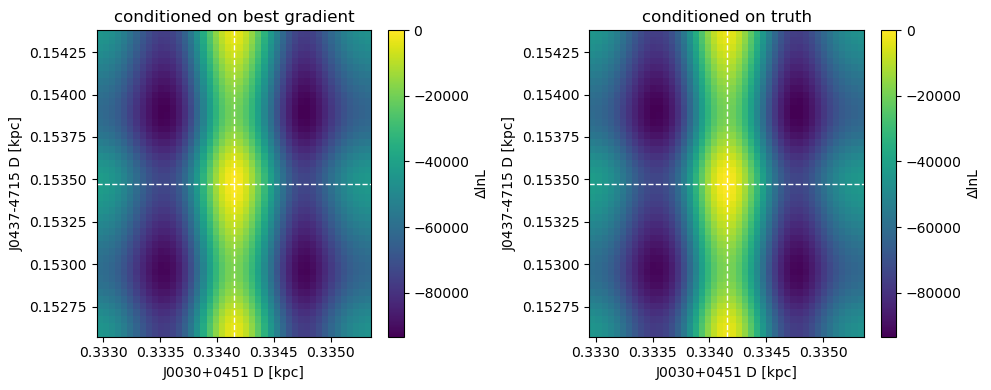

In [114]:
# Critical slice test for selected pair.
CRITICAL_PAIR = (0, 1) if N_PSR > 1 else None
if CRITICAL_PAIR is not None and "gradient_results" in globals():
    d_grad, _, _ = best_gradient_distance()
    i, j = CRITICAL_PAIR
    psr_i, psr_j = disco_psrs[i], disco_psrs[j]
    grid_i = np.unique(np.r_[np.linspace(max(0.01, truth_dist[i]-2*mode_spacings[i]), truth_dist[i]+2*mode_spacings[i], 45), truth_dist[i], d_grad[i]])
    grid_j = np.unique(np.r_[np.linspace(max(0.01, truth_dist[j]-2*mode_spacings[j]), truth_dist[j]+2*mode_spacings[j], 45), truth_dist[j], d_grad[j]])
    grad_values = set_distances(base_values, param_keys, disco_psrs, d_grad)
    _, _, surf_grad = scan_pulsar_pair_2d(logl_fn, grad_values, param_keys, distance_key(psr_i), distance_key(psr_j), grid_i, grid_j, chunk_size=CHUNK_SIZE, n_components=COMPONENTS)
    _, _, surf_truth = scan_pulsar_pair_2d(logl_fn, truth_values, param_keys, distance_key(psr_i), distance_key(psr_j), grid_i, grid_j, chunk_size=CHUNK_SIZE, n_components=COMPONENTS)
    for title, surf in [("conditioned on best gradient", surf_grad), ("conditioned on truth", surf_truth)]:
        pk = np.unravel_index(np.nanargmax(surf), surf.shape)
        ii = np.argmin(np.abs(grid_i - truth_dist[i])); jj = np.argmin(np.abs(grid_j - truth_dist[j]))
        print(title)
        print("  peak:", grid_i[pk[0]], grid_j[pk[1]], float(surf[pk]))
        print("  truth:", grid_i[ii], grid_j[jj], float(surf[ii, jj]))
        print("  ΔlnL truth-peak:", float(surf[ii, jj] - surf[pk]))
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), squeeze=False)
    for ax, surf, title in zip(axes[0], [surf_grad, surf_truth], ["conditioned on best gradient", "conditioned on truth"]):
        im = ax.pcolormesh(grid_j, grid_i, surf - np.nanmax(surf), shading="auto")
        ax.axhline(truth_dist[i], color="w", ls="--", lw=1); ax.axvline(truth_dist[j], color="w", ls="--", lw=1)
        ax.set_title(title); ax.set_xlabel(f"{psr_j.name} D [kpc]"); ax.set_ylabel(f"{psr_i.name} D [kpc]")
        plt.colorbar(im, ax=ax, label="ΔlnL")
    plt.tight_layout()
else:
    print("Run gradient optimizer first.")


In [115]:
# Gradient/curvature at best solution.
if "gradient_results" in globals():
    d_grad, _, _ = best_gradient_distance()
    z_best = (d_grad - prior_mean) / sigmas
    g = gradient_jac_np(z_best) if "gradient_jac_np" in globals() else np.full_like(z_best, np.nan)
    display(pd.DataFrame({"pulsar": [p.name for p in disco_psrs], "neg_logpost_grad_z": g, "abs_grad": np.abs(g)}).sort_values("abs_grad", ascending=False))
    if N_PSR <= 30:
        hess_diag_fn = jax.jit(lambda z: jnp.diag(jax.hessian(gradient_neg_obj_z)(z)))
        hdiag = np.asarray(hess_diag_fn(jnp.asarray(z_best, dtype=jnp.float64)), dtype=float)
        display(pd.DataFrame({
            "pulsar": [p.name for p in disco_psrs],
            "hess_diag_neg_logpost": hdiag,
            "local_max_logpost": hdiag > 0,
        }).sort_values("hess_diag_neg_logpost"))
    else:
        eps = 1e-4
        diag = []
        for i in range(min(5, N_PSR)):
            zp = z_best.copy(); zm = z_best.copy()
            zp[i] += eps; zm[i] -= eps
            gp = gradient_jac_np(zp)[i]
            gm = gradient_jac_np(zm)[i]
            diag.append((gp - gm) / (2 * eps))
        display(pd.DataFrame({"pulsar": [p.name for p in disco_psrs[:len(diag)]], "finite_diff_hess_diag_neg_logpost": diag, "local_max_logpost": np.asarray(diag) > 0}))
else:
    print("Run gradient optimizer first.")


,pulsar,neg_logpost_grad_z,abs_grad
18,J0751+1807,1.886722,1.886722
16,J2124-3358,-1.682190,1.682190
13,J1024-0719,-0.816406,0.816406
10,J1630+3734,0.567942,0.567942
0,J0437-4715,-0.440653,0.440653
19,J1045-4509,-0.242392,0.242392
7,J1012+5307,-0.218191,0.218191
1,J0030+0451,-0.191400,0.191400
5,J1713+0747,-0.173974,0.173974
2,J1744-1134,0.160941,0.160941


,pulsar,hess_diag_neg_logpost,local_max_logpost
0,J0437-4715,4.875490e+05,True
1,J0030+0451,1.401288e+07,True
2,J1744-1134,2.743510e+07,True
8,J1730-2304,1.536757e+08,True
12,J1737-0811,1.878204e+08,True
10,J1630+3734,2.529584e+08,True
11,J1614-2230,3.215739e+08,True
3,J1909-3744,3.755385e+08,True
4,J1022+1001,3.777441e+08,True
5,J1713+0747,4.036141e+08,True


In [116]:
# Cross-reference candidate truth coverage with gradient recovery.
if "gradient_results" in globals() and "mode_enum_df" in globals():
    d_grad, _, _ = best_gradient_distance()
    err_modes = (d_grad - truth_dist) / mode_spacings
    cross_ref = pd.DataFrame({
        "pulsar": [p.name for p in disco_psrs],
        "truth_in_candidates": mode_enum_df["truth_in_candidates"].values,
        "grad_err_modes": err_modes,
        "recovered_within_half_mode": np.abs(err_modes) < 0.5,
        "diagnosis": [
            "RECOVERED" if abs(err_modes[i]) < 0.5
            else ("coverage_fail" if not mode_enum_df["truth_in_candidates"].iloc[i]
                  else "optimizer_fail")
            for i in range(len(disco_psrs))
        ],
    })
    display(cross_ref)
    diag_counts = cross_ref["diagnosis"].value_counts()
    print("\nDiagnosis summary:")
    for d, count in diag_counts.items():
        print(f"  {d}: {count}/{len(disco_psrs)}")
else:
    print("Run gradient optimizer and mode enumeration first.")


,pulsar,truth_in_candidates,grad_err_modes,recovered_within_half_mode,diagnosis
0,J0437-4715,True,4.575242e-06,True,RECOVERED
1,J0030+0451,True,-6.348198e-07,True,RECOVERED
2,J1744-1134,True,8.801652e-07,True,RECOVERED
3,J1909-3744,True,1.109258e-08,True,RECOVERED
4,J1022+1001,True,8.381336e-09,True,RECOVERED
5,J1713+0747,True,7.774646e-08,True,RECOVERED
6,J0711-6830,True,1.038981e-07,True,RECOVERED
7,J1012+5307,True,-6.593524e-08,True,RECOVERED
8,J1730-2304,True,-1.380206e-07,True,RECOVERED
9,J2145-0750,True,1.592578e-07,True,RECOVERED



Diagnosis summary:
  RECOVERED: 20/20


## Beam Optimizer from Notebook 03

Copied for timing comparison. Default is off; set `RUN_BEAM_FOR_TIMING_COMPARISON=True` to run it in this notebook.


In [117]:
# Copied from notebook 03, with only the run toggle changed.
# Reuse Section B candidates so beam and gradient compare on the same mode pool.
if "mode_candidates" not in globals() and "all_pulsar_modes" in globals():
    # Evaluate actual lnL at each candidate for beam compatibility.
    # Use prior_mean context for all non-target pulsars.
    mode_candidates = []
    prior_ctx = set_distances(base_values, param_keys, disco_psrs, prior_mean)
    for i, m in enumerate(all_pulsar_modes):
        if len(m) == 0:
            mode_candidates.append({"distances": np.array([]), "lnL": np.array([]), "context": []})
            continue
        vals_batch, lls_batch = scan_pulsar_distance(
            logl_fn, prior_ctx, param_keys, distance_key(disco_psrs[i]),
            float(np.min(m)) - 0.001, float(np.max(m)) + 0.001,
            n_points=len(m),
            chunk_size=CHUNK_SIZE, n_components=COMPONENTS,
            required_points=list(m),
        )
        cand_lnL = np.array([float(np.interp(d, vals_batch, lls_batch)) for d in m])
        mode_candidates.append({
            "distances": np.asarray(m, dtype=float),
            "lnL": cand_lnL,
            "context": ["gradient_enum"] * len(m),
        })
    print(f"Built beam-compatible mode_candidates from gradient enumeration "
          f"({sum(len(mc['distances']) for mc in mode_candidates)} total candidates)")

RUN_BEAM_OPTIMIZER = RUN_BEAM_FOR_TIMING_COMPARISON


def make_initial_beam():
    states = []
    d_best = np.array([c["distances"][0] if len(c["distances"]) else prior_mean[i] for i, c in enumerate(mode_candidates)])
    for label, d in [("best_1d", d_best), ("prior_mean", prior_mean)]:
        vals = set_distances(base_values, param_keys, disco_psrs, d)
        states.append(dict(label=label, distances=d.copy(), values=vals, lnL=float(logl_fn(vals))))

    for rr in range(RAW_PRIOR_RANDOM_STATES):
        d = clipped_normal(prior_mean, sigmas, rng, CONTEXT_SIGMA_CLIP)
        vals = set_distances(base_values, param_keys, disco_psrs, d)
        states.append(dict(label=f"raw_prior_random_{rr}", distances=d, values=vals, lnL=float(logl_fn(vals))))

    for rr in range(BEAM_RANDOM_STATES):
        d = []
        for i, c in enumerate(mode_candidates):
            cd, cl = c["distances"], c["lnL"]
            if len(cd) == 0:
                d.append(prior_mean[i]); continue
            # Temper weights so random starts keep diversity instead of all choosing rank 0.
            w = np.exp(0.5 * (cl - np.nanmax(cl)))
            w = w / np.sum(w) if np.sum(w) > 0 else np.ones_like(w) / len(w)
            d.append(rng.choice(cd, p=w))
        d = np.asarray(d, dtype=float)
        vals = set_distances(base_values, param_keys, disco_psrs, d)
        states.append(dict(label=f"random_candidate_{rr}", distances=d, values=vals, lnL=float(logl_fn(vals))))
    return select_diverse_beam(states, BEAM_WIDTH)


def pair_candidate_proposals(state, i, j):
    """Return multiple pair-update proposals for one state.

    The old version returned only the best pair update, which can preserve a
    wrong local basin forever. Here we refine several center peaks and return
    several distinct pair assignments so beam selection can keep alternatives.
    """
    psr_i, psr_j = disco_psrs[i], disco_psrs[j]
    center_i = center_values_for_pulsar(state, i)
    center_j = center_values_for_pulsar(state, j)

    gi0, gj0, surf0 = scan_pulsar_pair_2d(
        logl_fn,
        state["values"],
        param_keys,
        distance_key(psr_i),
        distance_key(psr_j),
        center_i,
        center_j,
        chunk_size=CHUNK_SIZE,
        n_components=COMPONENTS,
    )

    candidates = []
    for mi, mj in top_surface_indices(surf0, PAIR_REFINE_TOP_N):
        grid_i = local_grid_single(float(gi0[mi]), i)
        grid_j = local_grid_single(float(gj0[mj]), j)
        gi, gj, surf = scan_pulsar_pair_2d(
            logl_fn,
            state["values"],
            param_keys,
            distance_key(psr_i),
            distance_key(psr_j),
            grid_i,
            grid_j,
            chunk_size=CHUNK_SIZE,
            n_components=COMPONENTS,
        )
        for ri, rj in top_surface_indices(surf, max(1, PAIR_PROPOSALS_PER_STATE)):
            candidates.append(dict(
                peak_lnL=float(surf[ri, rj]),
                peak_i=float(gi[ri]),
                peak_j=float(gj[rj]),
                grid_i=gi,
                grid_j=gj,
                lnL=surf,
                start_i=float(state["distances"][i]),
                start_j=float(state["distances"][j]),
            ))

    if not candidates:
        mi, mj = np.unravel_index(np.nanargmax(surf0), surf0.shape)
        candidates.append(dict(
            peak_lnL=float(surf0[mi, mj]),
            peak_i=float(gi0[mi]),
            peak_j=float(gj0[mj]),
            grid_i=gi0,
            grid_j=gj0,
            lnL=surf0,
            start_i=float(state["distances"][i]),
            start_j=float(state["distances"][j]),
        ))

    # Deduplicate by pair mode coordinates, keep top proposals.
    candidates = sorted(candidates, key=lambda c: c["peak_lnL"], reverse=True)
    out = []
    seen = set()
    for cand in candidates:
        key = (round(cand["peak_i"] / mode_spacings[i], 2), round(cand["peak_j"] / mode_spacings[j], 2))
        if key in seen:
            continue
        seen.add(key)
        new_d = state["distances"].copy()
        new_d[i] = cand["peak_i"]
        new_d[j] = cand["peak_j"]
        new_vals = set_distances(state["values"], param_keys, disco_psrs, new_d)
        out.append(dict(
            label=state.get("label", "beam"),
            distances=new_d,
            values=new_vals,
            lnL=cand["peak_lnL"],
            scan=cand,
        ))
        if len(out) >= PAIR_PROPOSALS_PER_STATE:
            break
    return out


def run_beam_optimizer():
    beam = make_initial_beam()
    history = []
    records = []
    step = 0
    t_start = time.time()
    print(f"initial beam: {len(beam)} states; pairs/sweep={len(pair_schedule)}; sweeps={BEAM_MAX_SWEEPS}")
    for rank, st in enumerate(beam):
        history.append(dict(step=step, sweep=-1, pair_index=-1, rank=rank, lnL=st["lnL"], label=st["label"], **recovery_score(st["distances"])))

    for sweep in range(BEAM_MAX_SWEEPS):
        sweep_t0 = time.time()
        for pair_index, (i, j) in enumerate(pair_schedule):
            pair_t0 = time.time()
            active = beam[:min(ACTIVE_BEAM_WIDTH_PER_PAIR, len(beam))]
            inactive = beam[min(ACTIVE_BEAM_WIDTH_PER_PAIR, len(beam)):]
            carry = [{k: v for k, v in st.items() if k != "scan"} for st in beam]
            updates = []
            for st in active:
                updates.extend(pair_candidate_proposals(st, i, j))
            # Seed non-monotonic bridge states every few pairs. These are cheap
            # full-likelihood evaluations and help escape high-likelihood but
            # wrong partial mode assignments.
            mutations = []
            if (pair_index % 5) == 0:
                for st in beam[:min(4, len(beam))]:
                    mutations.append(mutate_beam_state(st, n_mutations=2))
            proposals = carry + updates + inactive + mutations
            beam = select_diverse_beam(proposals, BEAM_WIDTH)
            step += 1
            for rank, st in enumerate(beam):
                history.append(dict(step=step, sweep=sweep, pair_index=pair_index, rank=rank, lnL=st["lnL"], label=st.get("label", "beam"), **recovery_score(st["distances"])))
            best = beam[0]
            best_update = max(updates, key=lambda st: st["lnL"]) if updates else None
            records.append(dict(
                step=step, sweep=sweep, pair_index=pair_index,
                i=i, j=j, psr_i=disco_psrs[i].name, psr_j=disco_psrs[j].name,
                truth_i=float(truth_dist[i]), truth_j=float(truth_dist[j]),
                scan=(best.get("scan") if best.get("scan") is not None else (best_update.get("scan") if best_update else None)),
                best_update_scan=(best_update.get("scan") if best_update else None),
                best_lnL=best["lnL"], best_update_lnL=(best_update["lnL"] if best_update else np.nan),
                start_i=(best_update.get("scan", {}).get("start_i", np.nan) if best_update else np.nan),
                start_j=(best_update.get("scan", {}).get("start_j", np.nan) if best_update else np.nan),
                best_state_has_scan=best.get("scan") is not None,
                best_score=recovery_score(best["distances"]),
                seconds=float(time.time() - pair_t0),
            ))
            if len(records) > KEEP_PAIR_RECORDS:
                records = records[-KEEP_PAIR_RECORDS:]

            if PROGRESS_EVERY_PAIR and ((pair_index + 1) % PROGRESS_EVERY_PAIR == 0):
                sc = records[-1]["best_score"]
                print(
                    f"sweep {sweep+1}/{BEAM_MAX_SWEEPS} pair {pair_index+1}/{len(pair_schedule)} "
                    f"{disco_psrs[i].name}/{disco_psrs[j].name} "
                    f"best_lnL={best['lnL']:.3f} frac0.5={sc['frac_within_half_mode']:.2f} "
                    f"med_modes={sc['median_abs_modes']:.3g} max_modes={sc['max_abs_modes']:.3g} pair_sec={records[-1]['seconds']:.2f}"
                )

            if PLOT_DURING_RUN and step % PLOT_EVERY_PAIR == 0:
                clear_output(wait=True)
                h = pd.DataFrame(history)
                best_h = h[h["rank"] == 0]
                fig, axes = plt.subplots(1, 3, figsize=(15, 4))
                axes[0].plot(best_h["step"], best_h["lnL"], ".-")
                axes[1].plot(best_h["step"], best_h["frac_within_half_mode"], ".-")
                axes[2].plot(best_h["step"], best_h["median_abs_modes"], ".-")
                axes[2].set_yscale("log")
                for ax in axes:
                    ax.grid(alpha=0.3); ax.set_xlabel("step")
                axes[0].set_ylabel("best lnL"); axes[1].set_ylabel("frac <0.5 mode"); axes[2].set_ylabel("median |err|/mode")
                plt.tight_layout(); plt.show()
        print(f"finished sweep {sweep+1}/{BEAM_MAX_SWEEPS} in {time.time()-sweep_t0:.1f}s")
    print(f"beam optimizer total seconds: {time.time()-t_start:.1f}")
    return beam, pd.DataFrame(history), records

if RUN_BEAM_OPTIMIZER:
    if "mode_candidates" not in globals():
        raise RuntimeError("Run candidate scan first.")
    beam_states, beam_history_df, beam_pair_records = run_beam_optimizer()
else:
    print("Set RUN_BEAM_OPTIMIZER=True and rerun this cell.")

Set RUN_BEAM_OPTIMIZER=True and rerun this cell.


## Section F - Timing Comparison

Optional beam run can be copied/run from notebook 03 in this notebook session, or run notebook 03 side by side. This table fills gradient metrics immediately and beam metrics when `beam_states` exists.

In [118]:
def timing_comparison_table():
    grad_d, grad_lnL, grad_logpost = best_gradient_distance() if "gradient_results" in globals() else (None, np.nan, np.nan)
    grad_score = recovery_score(grad_d) if grad_d is not None else {}
    rows = []
    if "beam_states" in globals() and beam_states:
        b = beam_states[0]
        bscore = recovery_score(b["distances"])
        rows.append(dict(method="Beam", wall_clock_seconds=np.nan, total_likelihood_evals=np.nan, best_lnL=b["lnL"], best_logpost=np.nan, **bscore))
    rows.append(dict(method="Gradient", wall_clock_seconds=sum(r.get("seconds", 0.0) for r in gradient_results) if "gradient_results" in globals() else np.nan, total_likelihood_evals=sum(r.get("nfev", 0) for r in gradient_results) if "gradient_results" in globals() else np.nan, best_lnL=grad_lnL, best_logpost=grad_logpost, **grad_score))
    return pd.DataFrame(rows)

if "gradient_results" in globals():
    display(timing_comparison_table())
else:
    print("Run gradient optimizer first.")


,method,wall_clock_seconds,total_likelihood_evals,best_lnL,best_logpost,frac_within_half_mode,frac_within_one_mode,median_abs_modes,max_abs_modes,median_abs_sigma,max_abs_sigma
0,Gradient,120.016034,13977,105246.352407,105234.456923,1.0,1.0,9.638753e-08,0.000005,1.294646e-09,0.000002


## Section G - Recovery Demonstration Plots

Presentation plots showing recovery quality, 1D multimodality, likelihood progression, and a 2D critical slice.


Saved 4 plot sets to current directory


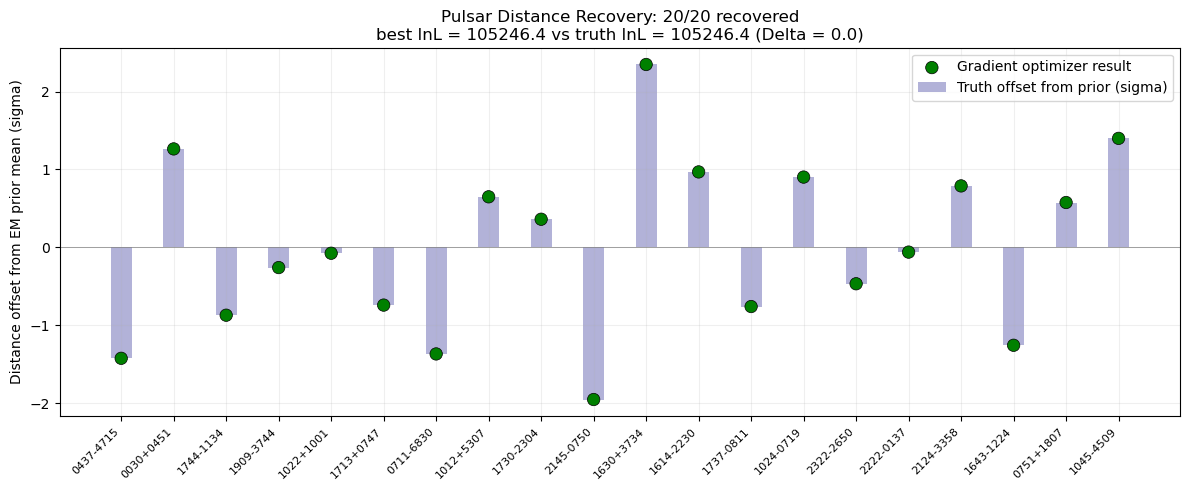

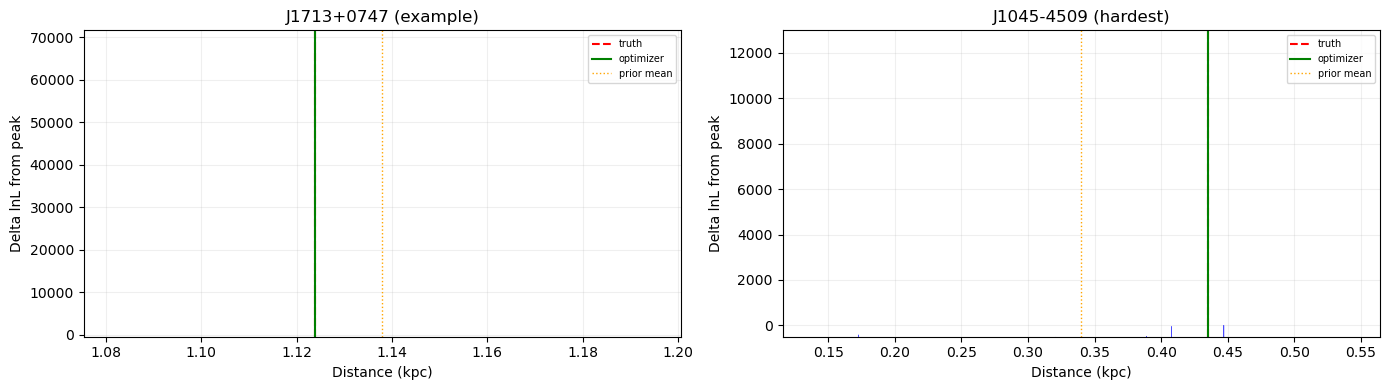

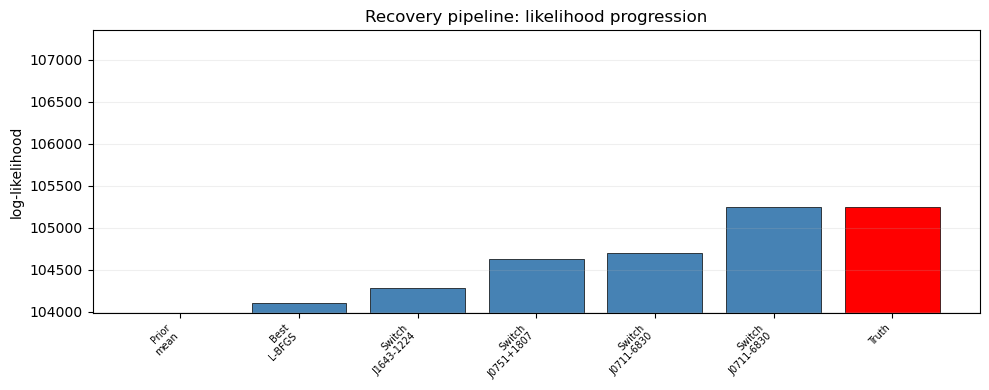

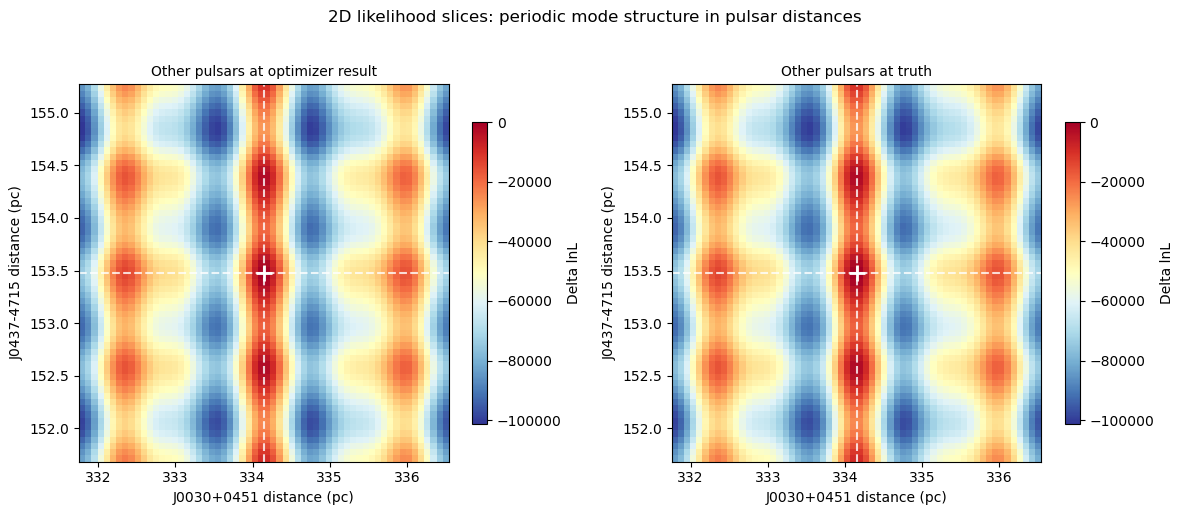

In [119]:
if "gradient_results" in globals():
    d_grad, lnL_grad, logpost_grad = best_gradient_distance()
    err_modes = (d_grad - truth_dist) / mode_spacings
    if "cross_ref" not in globals():
        cross_ref = pd.DataFrame({
            "pulsar": [p.name for p in disco_psrs],
            "recovered_within_half_mode": np.abs(err_modes) < 0.5,
        })

    # Plot 1: per-pulsar recovery summary.
    fig1, ax = plt.subplots(figsize=(12, 5))
    psr_names = [p.name.replace("J", "") for p in disco_psrs]
    x = np.arange(len(disco_psrs))
    truth_offset_sigma = (truth_dist - prior_mean) / sigmas
    grad_offset_sigma = (d_grad - prior_mean) / sigmas
    ax.bar(x, truth_offset_sigma, width=0.4, alpha=0.3, color="navy", label="Truth offset from prior (sigma)")
    ax.scatter(
        x, grad_offset_sigma, s=80, zorder=5,
        c=["green" if abs(e) < 0.5 else "red" for e in err_modes],
        edgecolors="black", linewidths=0.5,
        label="Gradient optimizer result",
    )
    ax.axhline(0, color="gray", ls="-", lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(psr_names, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Distance offset from EM prior mean (sigma)")
    recovered_n = int(np.sum(np.abs(err_modes) < 0.5))
    ax.set_title(
        f"Pulsar Distance Recovery: {recovered_n}/{len(disco_psrs)} recovered\n"
        f"best lnL = {lnL_grad:.1f} vs truth lnL = {truth_lnL:.1f} (Delta = {truth_lnL - lnL_grad:.1f})"
    )
    ax.legend(loc="upper right")
    ax.grid(alpha=0.2)
    plt.tight_layout()

    # Plot 2: 1D scans for a recovered pulsar and the hardest pulsar.
    fig2, axes = plt.subplots(1, 2, figsize=(14, 4))
    scan_examples = [(min(5, N_PSR - 1), f"{disco_psrs[min(5, N_PSR - 1)].name} (example)"), (N_PSR - 1, f"{disco_psrs[N_PSR - 1].name} (hardest)")]
    for ax, (idx, title) in zip(axes, scan_examples):
        psr = disco_psrs[idx]
        lo, hi, n_pts = candidate_grid_bounds(idx)
        ctx = set_distances(base_values, param_keys, disco_psrs, d_grad)
        vals, lls = scan_pulsar_distance(
            logl_fn, ctx, param_keys, distance_key(psr),
            lo, hi, n_points=min(n_pts, 2000), chunk_size=CHUNK_SIZE,
            n_components=COMPONENTS,
        )
        y = lls - np.nanmax(lls)
        ax.plot(vals, y, "b-", lw=0.5, alpha=0.7)
        ax.axvline(truth_dist[idx], color="red", ls="--", lw=1.5, label="truth")
        ax.axvline(d_grad[idx], color="green", ls="-", lw=1.5, label="optimizer")
        ax.axvline(prior_mean[idx], color="orange", ls=":", lw=1, label="prior mean")
        ax.set_xlabel("Distance (kpc)")
        ax.set_ylabel("Delta lnL from peak")
        ax.set_title(title)
        ax.legend(fontsize=7)
        ax.set_ylim(bottom=max(-500, np.nanmin(y)))
        ax.grid(alpha=0.2)
    plt.tight_layout()

    # Plot 3: lnL progression.
    fig3, ax = plt.subplots(figsize=(10, 4))
    stages = ["Prior\nmean"]
    lnLs = [prior_mean_lnL]
    stages.append("Best\nL-BFGS")
    lnLs.append(gradient_results[0]["lnL"])
    if "best_gradient_refined" in globals() and len(best_gradient_refined["accepted"]):
        for _, row in best_gradient_refined["accepted"].iterrows():
            stages.append(f"Switch\n{row['pulsar']}")
            lnLs.append(row["lnL"])
    stages.append("Truth")
    lnLs.append(truth_lnL)
    x_stage = np.arange(len(stages))
    colors = ["gray"] + ["steelblue"] * (len(stages) - 2) + ["red"]
    ax.bar(x_stage, lnLs, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_xticks(x_stage)
    ax.set_xticklabels(stages, fontsize=7, rotation=45, ha="right")
    ax.set_ylabel("log-likelihood")
    ax.set_title("Recovery pipeline: likelihood progression")
    if len(lnLs) > 2:
        ymin = min(lnLs[1:]) - 0.1 * abs(max(lnLs[1:]) - min(lnLs[1:]))
        ymax = max(lnLs) * 1.02
        ax.set_ylim(ymin, ymax)
    ax.grid(alpha=0.2, axis="y")
    plt.tight_layout()

    # Plot 4: 2D critical slice.
    fig4, axes = plt.subplots(1, 2, figsize=(12, 5))
    i, j = 0, 1
    psr_i, psr_j = disco_psrs[i], disco_psrs[j]
    n_grid = 60
    grid_i = np.linspace(max(0.01, truth_dist[i] - 4 * mode_spacings[i]), truth_dist[i] + 4 * mode_spacings[i], n_grid)
    grid_j = np.linspace(max(0.01, truth_dist[j] - 4 * mode_spacings[j]), truth_dist[j] + 4 * mode_spacings[j], n_grid)
    grad_ctx = set_distances(base_values, param_keys, disco_psrs, d_grad)
    truth_ctx = set_distances(base_values, param_keys, disco_psrs, truth_dist)
    _, _, surf_grad = scan_pulsar_pair_2d(
        logl_fn, grad_ctx, param_keys,
        distance_key(psr_i), distance_key(psr_j),
        grid_i, grid_j, chunk_size=CHUNK_SIZE, n_components=COMPONENTS,
    )
    _, _, surf_truth = scan_pulsar_pair_2d(
        logl_fn, truth_ctx, param_keys,
        distance_key(psr_i), distance_key(psr_j),
        grid_i, grid_j, chunk_size=CHUNK_SIZE, n_components=COMPONENTS,
    )
    for ax, surf, title in zip(axes, [surf_grad, surf_truth], ["Other pulsars at optimizer result", "Other pulsars at truth"]):
        im = ax.pcolormesh(grid_j * 1000, grid_i * 1000, surf - np.nanmax(surf), shading="auto", cmap="RdYlBu_r")
        ax.axhline(truth_dist[i] * 1000, color="white", ls="--", lw=1.5, alpha=0.8)
        ax.axvline(truth_dist[j] * 1000, color="white", ls="--", lw=1.5, alpha=0.8)
        ax.plot(truth_dist[j] * 1000, truth_dist[i] * 1000, "w+", ms=12, mew=2)
        ax.set_xlabel(f"{psr_j.name} distance (pc)", fontsize=10)
        ax.set_ylabel(f"{psr_i.name} distance (pc)", fontsize=10)
        ax.set_title(title, fontsize=10)
        plt.colorbar(im, ax=ax, label="Delta lnL", shrink=0.8)
    fig4.suptitle("2D likelihood slices: periodic mode structure in pulsar distances", fontsize=12, y=1.02)
    plt.tight_layout()

    for name, fig in [("recovery_summary", fig1), ("1d_scans", fig2), ("convergence", fig3), ("2d_slices", fig4)]:
        fig.savefig(f"04_{name}.pdf", bbox_inches="tight", dpi=150)
        fig.savefig(f"04_{name}.png", bbox_inches="tight", dpi=150)
    print("Saved 4 plot sets to current directory")
else:
    print("Run gradient optimizer first.")


## Staged Tests

Run sequentially with small `N_PSR`/`N_CW` settings when changing internals. These cells report pass/fail diagnostics; stochastic recovery is diagnostic only.

In [120]:
# Test 3: full-vector L-BFGS from truth. Tests gradient machinery end-to-end.
if RUN_TEST_FULL_TRUTH_START:
    opt_test_bundle = make_distance_optimizer(logl_fn, param_keys, base_values, disco_psrs, prior_mean, sigmas, MODE_PRIOR_SIGMA_WIDTH, objective="logpost", maxiter=50)
    opt_test = opt_test_bundle[0]
    d_opt, lnL, logpost, info = opt_test(truth_dist)
    print("success:", info["success"], info["message"])
    print("nit:", info.get("nit"), "grad_norm:", info["grad_norm"])
    print("lnL(opt)-lnL(truth):", lnL - truth_lnL)
    print("max |err| modes:", np.max(np.abs((d_opt - truth_dist) / mode_spacings)))
    assert info.get("nit", 999) <= 50
    assert lnL >= truth_lnL - 0.01
    assert np.all(np.abs((d_opt - truth_dist) / mode_spacings) < 0.3)
else:
    print("Set RUN_TEST_FULL_TRUTH_START=True for Test 3.")


success: False STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
nit: 50 grad_norm: 1.092817304317064
lnL(opt)-lnL(truth): -2.2751919459551573e-06
max |err| modes: 6.75135296020244e-06
